In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')

In [7]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/train.csv')
display(df.head())

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [8]:
print("Shape of Dataset:",df.shape)

print("\nColumns:")
print(df.columns)

print("\nInformation:")
df.info()

Shape of Dataset: (9800, 18)

Columns:
Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   

In [9]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

print(df[['Order Date','Ship Date']].head())

  Order Date  Ship Date
0 2017-11-08 2017-11-11
1 2017-11-08 2017-11-11
2 2017-06-12 2017-06-16
3 2016-10-11 2016-10-18
4 2016-10-11 2016-10-18


In [10]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month Name'] = df['Order Date'].dt.month_name()
df['Quarter'] = df['Order Date'].dt.quarter
df['Week'] = df['Order Date'].dt.isocalendar().week
df['Day'] = df['Order Date'].dt.day_name()

In [11]:
print(df.isnull().sum())

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Year              0
Month             0
Month Name        0
Quarter           0
Week              0
Day               0
dtype: int64


No significant missing values were found in the dataset.

In [12]:
print("Duplicate Rows=",df.duplicated().sum())

Duplicate Rows= 0


No duplicate records were found.

In [13]:
print(df.dtypes)

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code             float64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Year                      int32
Month                     int32
Month Name               object
Quarter                   int32
Week                     UInt32
Day                      object
dtype: object


In [14]:
daily_sales = df.groupby('Order Date')['Sales'].sum()

weekly_sales = df.groupby(pd.Grouper(key='Order Date', freq='W'))['Sales'].sum()

monthly_sales = df.groupby(pd.Grouper(key='Order Date', freq='ME'))['Sales'].sum()

print(monthly_sales.head())

Order Date
2015-01-31    14205.707
2015-02-28     4519.892
2015-03-31    55205.797
2015-04-30    27906.855
2015-05-31    23644.303
Freq: ME, Name: Sales, dtype: float64


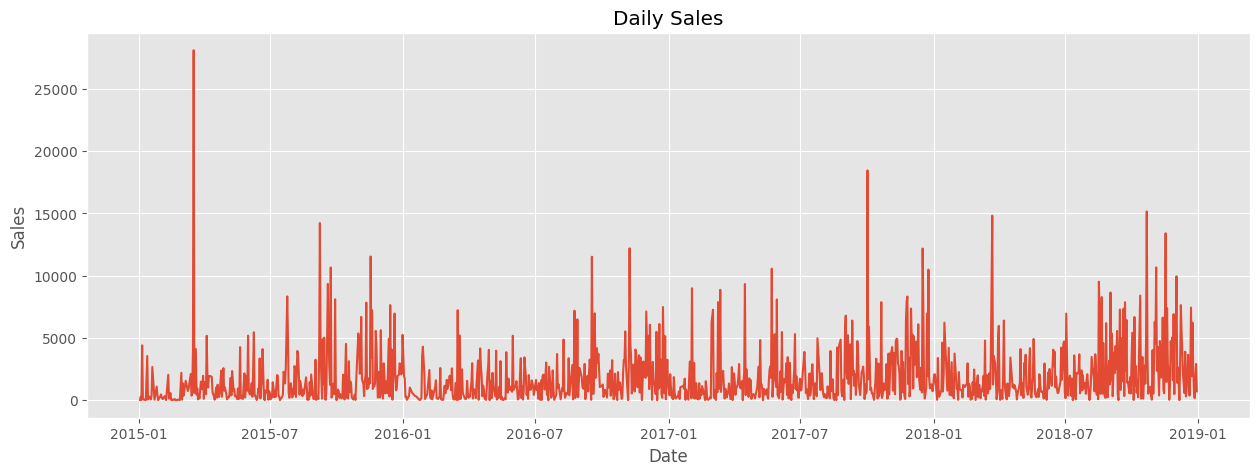

In [15]:
plt.figure(figsize=(15,5))

plt.plot(daily_sales)

plt.title("Daily Sales")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.show()

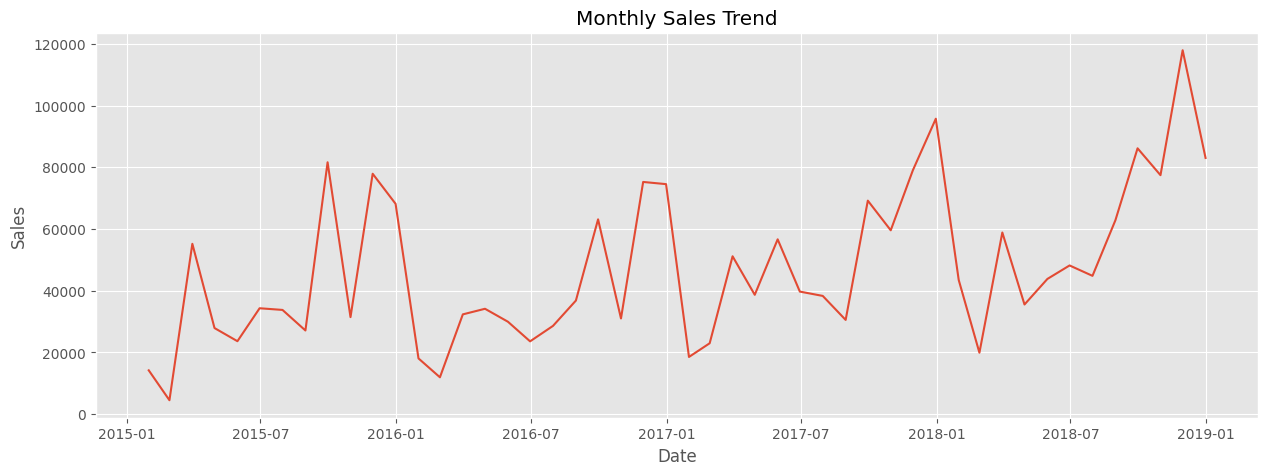

In [16]:
plt.figure(figsize=(15,5))

plt.plot(monthly_sales)

plt.title("Monthly Sales Trend")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.show()

In [17]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

print(category_sales)

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


Technology category generated the highest sales revenue.

Region      Central        East        South         West
Year                                                     
2015    102920.5206  127652.819  103374.9055  145907.9630
2016    102425.1724  153225.183   70076.0825  133709.5675
2017    145673.8800  178511.538   93535.9035  182471.2285
2018    141627.3402  210129.186  122164.5675  248130.9255


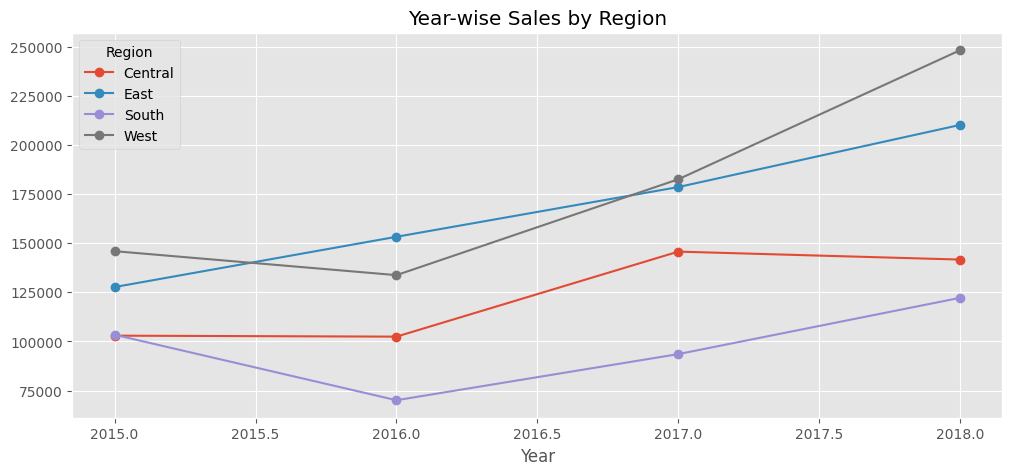

In [18]:
region_sales = df.groupby(['Year','Region'])['Sales'].sum().unstack()

print(region_sales)

region_sales.plot(figsize=(12,5), marker='o')

plt.title("Year-wise Sales by Region")

plt.show()

The region with the most consistent growth can be identified from the graph.

In [19]:
df['Shipping Days']=(df['Ship Date']-df['Order Date']).dt.days

print("Average Shipping Time =",df['Shipping Days'].mean())

Average Shipping Time = 3.9611224489795918


In [20]:
shipping=df.groupby('Region')['Shipping Days'].mean()

print(shipping)

Region
Central    4.065876
East       3.910233
South      3.961202
West       3.930255
Name: Shipping Days, dtype: float64


Shipping time varies slightly across different regions.

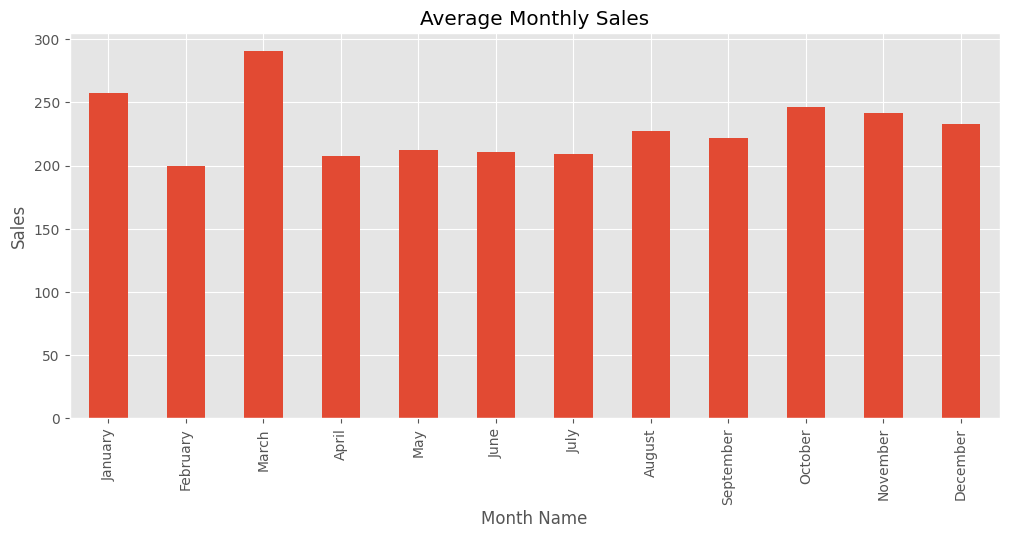

In [21]:
seasonality=df.groupby('Month Name')['Sales'].mean()

seasonality=seasonality.reindex([
'January',
'February',
'March',
'April',
'May',
'June',
'July',
'August',
'September',
'October',
'November',
'December'
])

seasonality.plot(kind='bar',figsize=(12,5))

plt.title("Average Monthly Sales")

plt.ylabel("Sales")

plt.show()

The months with consistently high sales indicate seasonality.

In [22]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

In [86]:
monthly_sales = df.groupby(pd.Grouper(key='Order Date', freq='ME'))['Sales'].sum()

monthly_sales.head()

,Sales
Order Date,
2015-01-31,14205.707
2015-02-28,4519.892
2015-03-31,55205.797
2015-04-30,27906.855
2015-05-31,23644.303


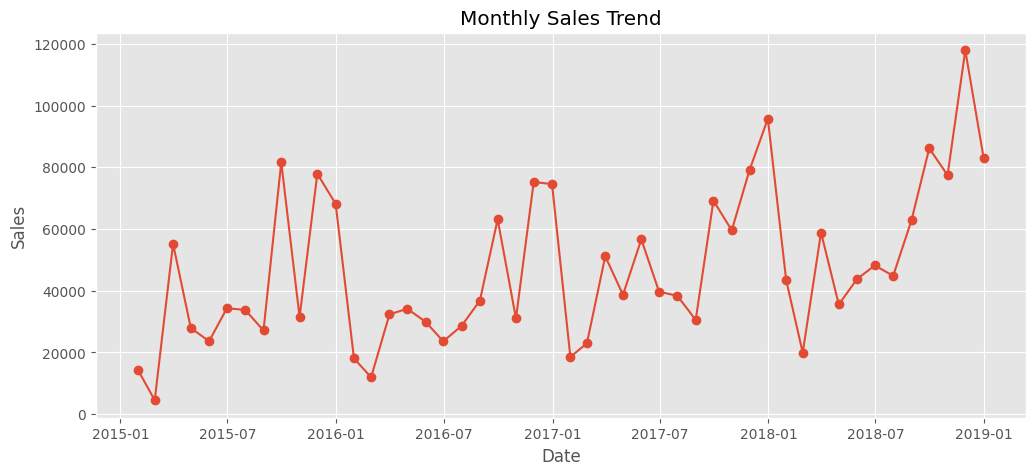

In [24]:
monthly_sales = df.set_index('Order Date').groupby(pd.Grouper(freq='ME'))['Sales'].sum()

plt.figure(figsize=(12,5))

plt.plot(monthly_sales, marker='o')

plt.title("Monthly Sales Trend")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.grid(True)

plt.show()

The graph shows the monthly sales trend over time.
Sales fluctuate across months,indicating possible seasonality.

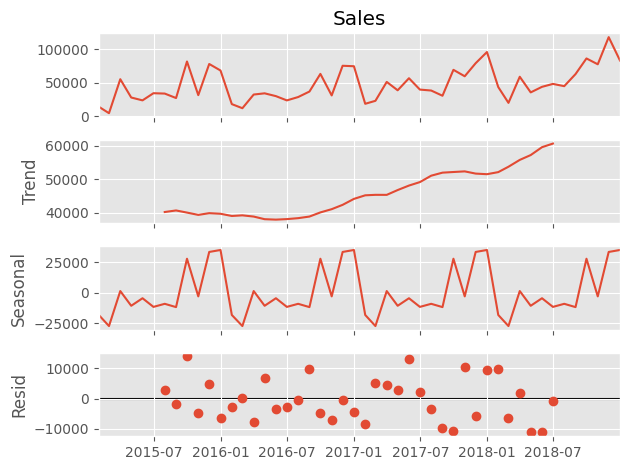

In [25]:
decomposition = seasonal_decompose(
    monthly_sales,
    model='additive',
    period=12
)

decomposition.plot()

plt.show()

The decomposition separates the data into Trend, Seasonal, and Residual components.

In [26]:
result = adfuller(monthly_sales)

print("ADF Statistic :", result[0])
print("p-value :", result[1])

if result[1] < 0.05:
    print("The time series is Stationary.")
else:
    print("The time series is Non-Stationary.")

ADF Statistic : -4.416136761430769
p-value : 0.00027791039276670623
The time series is Stationary.


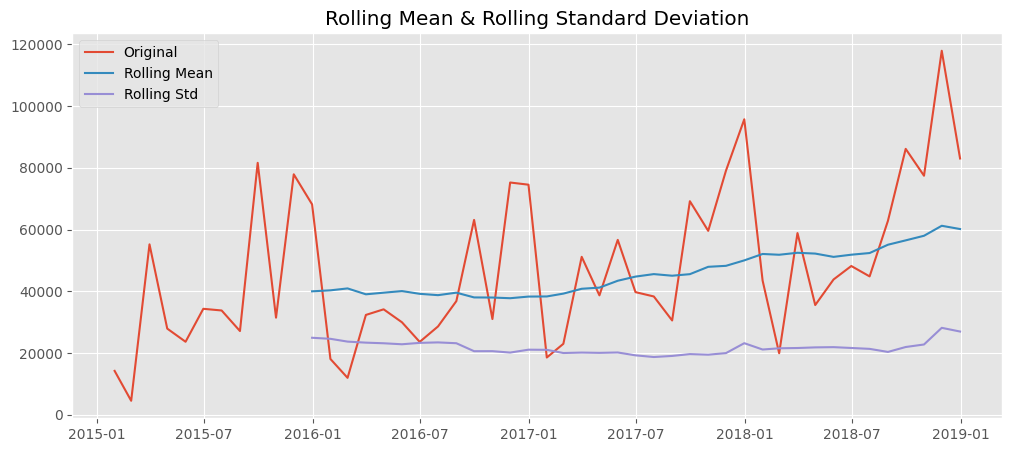

In [27]:
rolling_mean = monthly_sales.rolling(window=12).mean()
rolling_std = monthly_sales.rolling(window=12).std()

plt.figure(figsize=(12,5))

plt.plot(monthly_sales, label='Original')
plt.plot(rolling_mean, label='Rolling Mean')
plt.plot(rolling_std, label='Rolling Std')

plt.legend()

plt.title("Rolling Mean & Rolling Standard Deviation")

plt.show()

Rolling statistics help determine whether the series remains stable over time.

In [28]:
!pip install prophet
!pip install xgboost

In [29]:
from prophet import Prophet
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
import numpy as np


In [30]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
monthly_sales = df.groupby(pd.Grouper(key='Order Date', freq='ME'))['Sales'].sum().reset_index()

monthly_sales.columns = ['ds', 'y']

monthly_sales.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [31]:
train = monthly_sales[:-12]
test = monthly_sales[-12:]

print(train.shape)
print(test.shape)

(36, 2)
(12, 2)


Part A : SARIMA

In [32]:
train_series=train.set_index('ds')['y']

In [87]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
sarima = SARIMAX(
    train_series,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

sarima_fit=sarima.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


In [34]:
forecast_sarima=sarima_fit.forecast(12)

forecast_sarima

,predicted_mean
2018-01-31,54763.420652
2018-02-28,52819.129019
2018-03-31,76002.371427
2018-04-30,64500.170367
2018-05-31,73035.281008
2018-06-30,63066.853721
2018-07-31,62398.658205
2018-08-31,57826.578547
2018-09-30,89850.367072
2018-10-31,74041.611144


In [35]:
actual_values = test['y'].values
predicted_values = forecast_sarima.values

sarima_mae = mean_absolute_error(actual_values, predicted_values)
sarima_rmse = np.sqrt(mean_squared_error(actual_values, predicted_values))

sarima_mape = np.mean(np.abs((actual_values - predicted_values) / actual_values)) * 100

print("MAE =", sarima_mae)
print("RMSE =", sarima_rmse)
print("MAPE =", sarima_mape)

MAE = 17267.9345820592
RMSE = 19805.400812980435
MAPE = 41.61297147614309


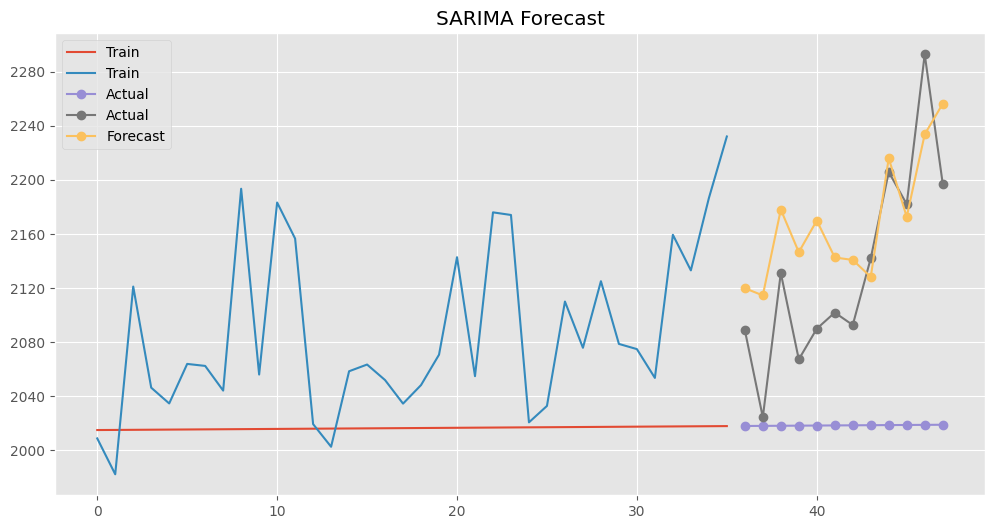

In [36]:
plt.figure(figsize=(12,6))

plt.plot(train.index, train, label="Train")

plt.plot(test.index, test, label="Actual", marker="o")

plt.plot(test.index, forecast_sarima, label="Forecast", marker="o")

plt.legend()

plt.title("SARIMA Forecast")

plt.show()

Part B - Fcebook Prophet

In [37]:
prophet_model = Prophet()

prophet_model.fit(train)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [88]:
future = prophet_model.make_future_dataframe(periods=12, freq='ME')

forecast = prophet_model.predict(future)

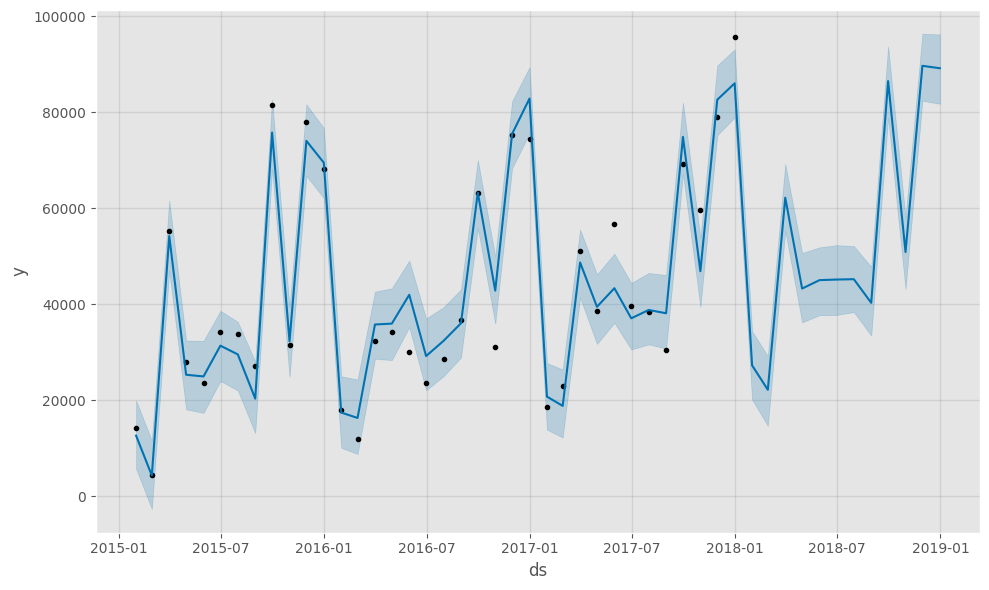

In [39]:
import matplotlib.pyplot as plt
prophet_model.plot(forecast)
plt.show()

In [40]:
pred = forecast[['ds','yhat']].tail(12)

prophet_mae = mean_absolute_error(test['y'], pred['yhat'])

prophet_rmse = np.sqrt(mean_squared_error(test['y'], pred['yhat']))

prophet_mape = np.mean(np.abs((test['y']-pred['yhat'])/test['y']))*100

print("MAE =",prophet_mae)
print("RMSE =",prophet_rmse)
print("MAPE =",prophet_mape)

MAE = 9839.837156541647
RMSE = 14133.075195359734
MAPE = 15.668720446761983


Part C : XGBoost

In [41]:
monthly_sales['Month']=monthly_sales['ds'].dt.month
monthly_sales['Year']=monthly_sales['ds'].dt.year

In [42]:
X=monthly_sales[['Month','Year']]

y=monthly_sales['y']

In [43]:
X_train=X[:-12]

X_test=X[-12:]

y_train=y[:-12]

y_test=y[-12:]

In [44]:
model=XGBRegressor()

model.fit(X_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [45]:
prediction=model.predict(X_test)

In [46]:
xgb_mae=mean_absolute_error(y_test,prediction)

xgb_rmse=np.sqrt(mean_squared_error(y_test,prediction))

xgb_mape=np.mean(np.abs((y_test-prediction)/y_test))*100

print("MAE =",xgb_mae)

print("RMSE =",xgb_rmse)

print("MAPE =",xgb_mape)

MAE = 15444.166120833333
RMSE = 18932.06867506305
MAPE = 24.86465184049899


In [47]:
results = pd.DataFrame({
    "Model":["Prophet","SARIMA","XGBoost"],
    "MAE":[prophet_mae,sarima_mae,xgb_mae],
    "RMSE":[prophet_rmse,sarima_rmse,xgb_rmse],
    "MAPE":[prophet_mape,sarima_mape,xgb_mape]
})

results

,Model,MAE,RMSE,MAPE
0,Prophet,9839.837157,14133.075195,15.668720
1,SARIMA,17267.934582,19805.400813,41.612971
2,XGBoost,15444.166121,18932.068675,24.864652


In [48]:
category_monthly = df.groupby(
    ['Category', pd.Grouper(key='Order Date', freq='ME')]
)['Sales'].sum().reset_index()

category_monthly.head()

,Category,Order Date,Sales
0,Furniture,2015-01-31,6217.277
1,Furniture,2015-02-28,1839.658
2,Furniture,2015-03-31,14243.368
3,Furniture,2015-04-30,7944.837
4,Furniture,2015-05-31,6912.787


In [49]:
def category_region_forecast(data, title):

    # Monthly Sales
    monthly = data.groupby(pd.Grouper(key='Order Date', freq='ME'))['Sales'].sum().reset_index()

    # Rename columns for Prophet
    monthly.columns = ['ds', 'y']

    # Create Model
    model = Prophet()

    # Train Model
    model.fit(monthly)

    # Forecast next 3 months
    future = model.make_future_dataframe(periods=3, freq='ME')

    forecast = model.predict(future)

    # Plot Forecast
    model.plot(forecast)
    plt.title(title)
    plt.show()

    return forecast

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


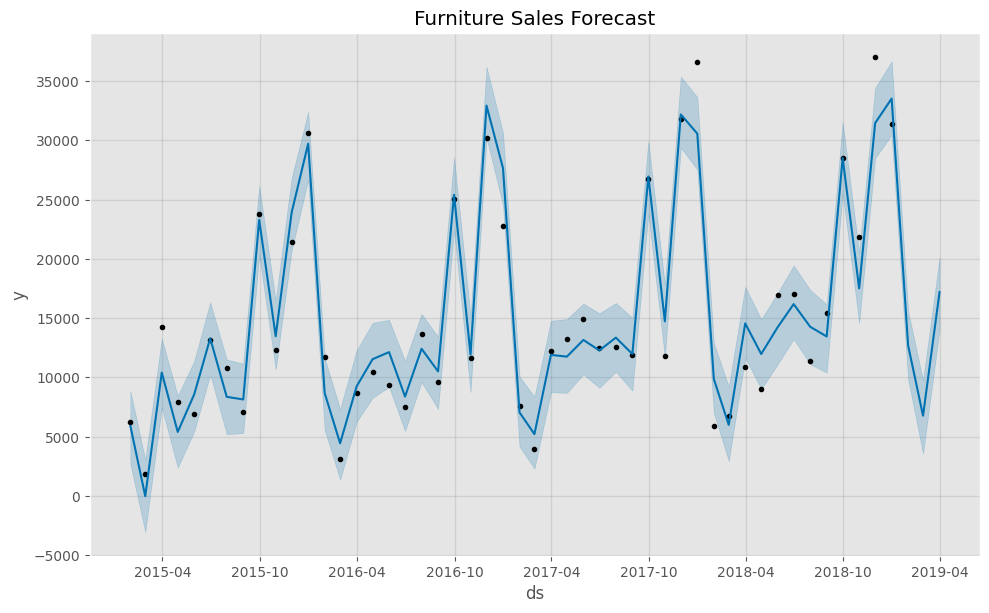

In [50]:
furniture = df[df['Category'] == 'Furniture']

forecast_furniture = category_region_forecast(
    furniture,
    "Furniture Sales Forecast"
)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


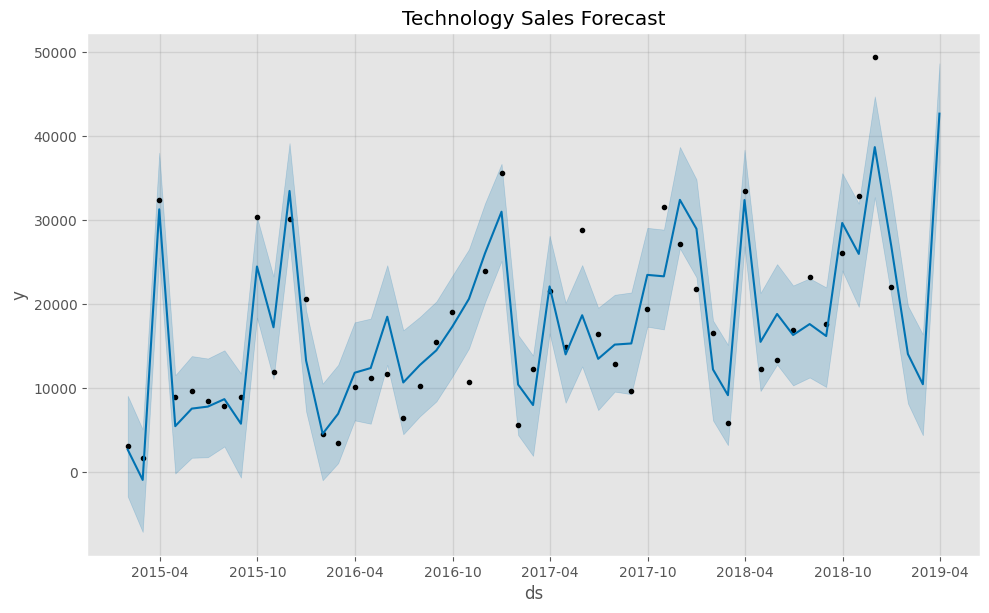

In [51]:
technology = df[df['Category'] == 'Technology']

forecast_technology = category_region_forecast(
    technology,
    "Technology Sales Forecast"
)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


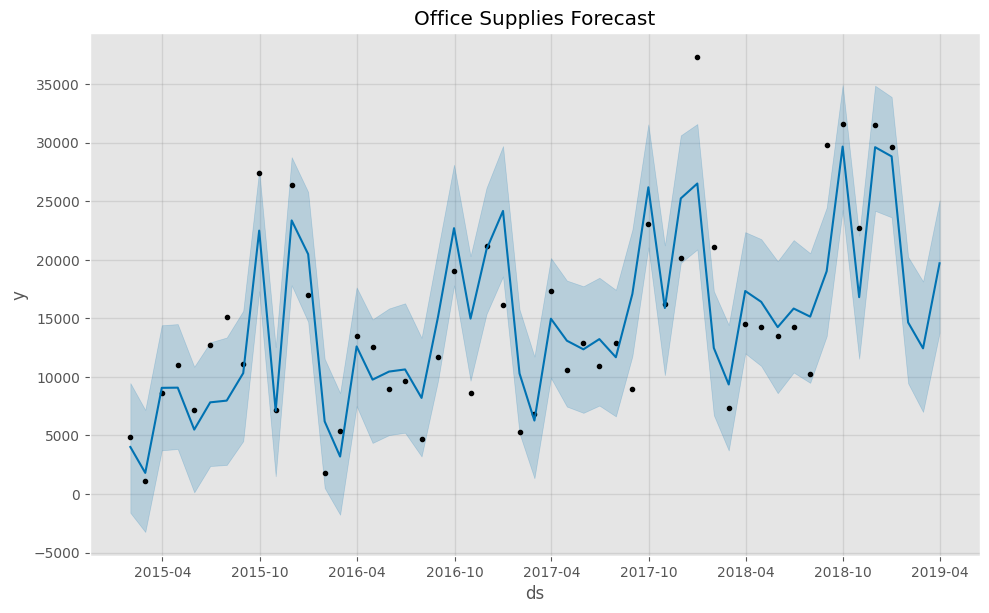

In [52]:
office = df[df['Category'] == 'Office Supplies']

forecast_office = category_region_forecast(
    office,
    "Office Supplies Forecast"
)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


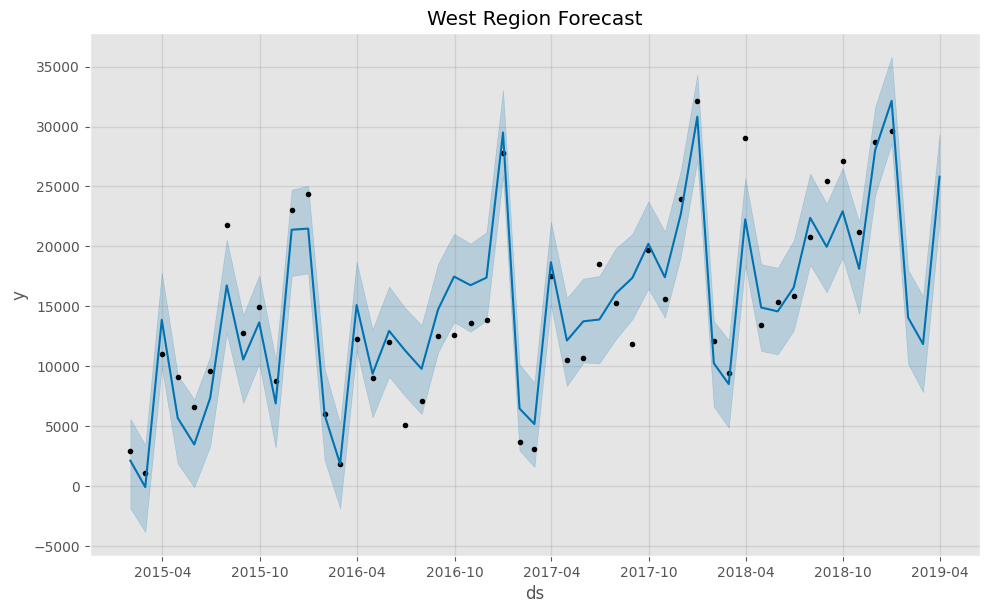

In [53]:
west = df[df['Region'] == 'West']

forecast_west = category_region_forecast(
    west,
    "West Region Forecast"
)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


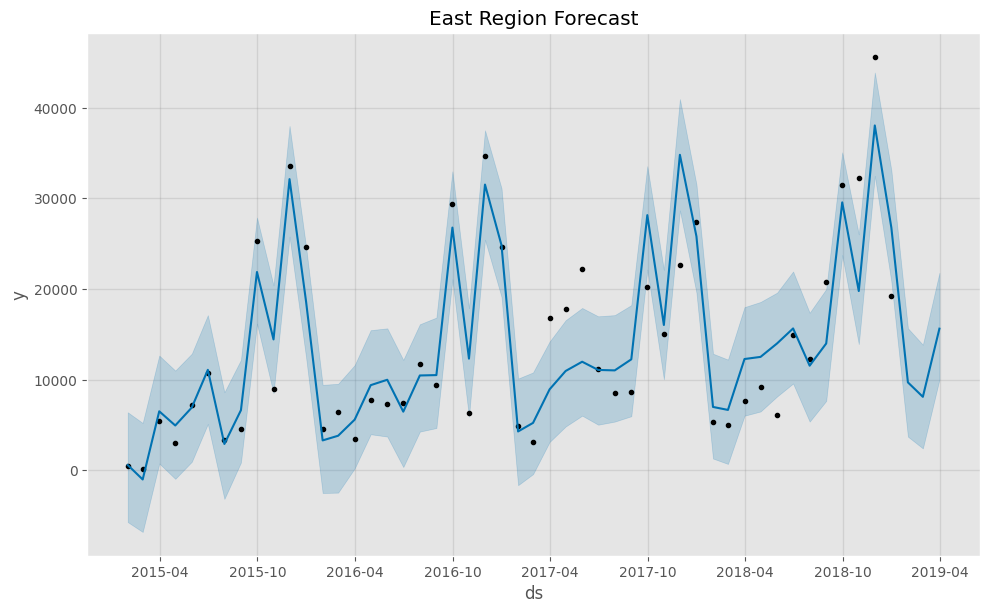

In [54]:
east = df[df['Region'] == 'East']

forecast_east = category_region_forecast(
    east,
    "East Region Forecast"
)

In [55]:
comparison = pd.DataFrame({

    "Furniture": forecast_furniture["yhat"].tail(3).values,

    "Technology": forecast_technology["yhat"].tail(3).values,

    "Office Supplies": forecast_office["yhat"].tail(3).values,

    "West": forecast_west["yhat"].tail(3).values,

    "East": forecast_east["yhat"].tail(3).values

})

comparison.index = ["Month 1", "Month 2", "Month 3"]

comparison

,Furniture,Technology,Office Supplies,West,East
Month 1,12691.392668,14033.343185,14646.724651,14048.800867,9713.411357
Month 2,6772.162417,10437.986784,12434.656284,11840.373145,8120.218592
Month 3,17201.015649,42639.488041,19698.155527,25805.336379,15639.421337


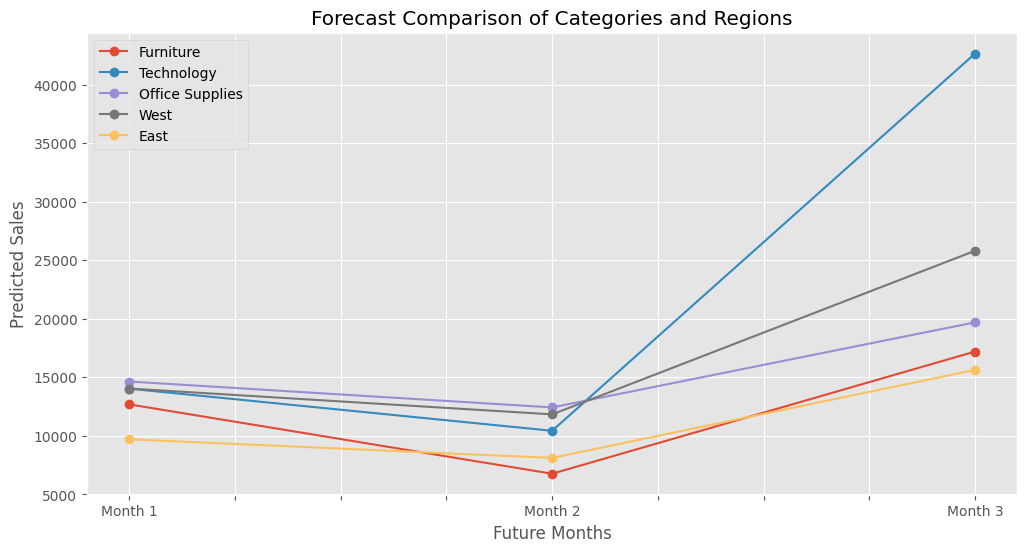

In [56]:
comparison.plot(figsize=(12,6), marker='o')

plt.title("Forecast Comparison of Categories and Regions")

plt.xlabel("Future Months")

plt.ylabel("Predicted Sales")

plt.grid(True)

plt.show()

In [57]:
growth = comparison.iloc[-1]

print("Forecast for Third Month:\n")

print(growth)

print("\nStrongest Growth:")

print(growth.idxmax())

Forecast for Third Month:

Furniture          17201.015649
Technology         42639.488041
Office Supplies    19698.155527
West               25805.336379
East               15639.421337
Name: Month 3, dtype: float64

Strongest Growth:
Technology


* Prophet model was applied to each product category and selected regions.
* Forecasts for the next 3 months were generated.
* A comparison chart was created to compare all forecasts.
* The category/region with the highest predicted sales in the final forecast month is identified as the strongest upcoming growth segment.

In [58]:

from sklearn.ensemble import IsolationForest
from scipy.stats import zscore


In [59]:
anomaly_df = pd.read_csv("/content/drive/MyDrive/vgsales.csv (1).zip")

anomaly_df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [60]:
print(anomaly_df.columns)

anomaly_df.info()

Index(['Rank', 'Name', 'Platform', 'Year', 'Genre', 'Publisher', 'NA_Sales',
       'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


In [61]:
weekly_sales = anomaly_df.groupby("Year")["Global_Sales"].sum().reset_index()

weekly_sales.columns = ["Week","Sales"]

weekly_sales.head()

,Week,Sales
0,1980.0,11.38
1,1981.0,35.77
2,1982.0,28.86
3,1983.0,16.79
4,1984.0,50.36


In [62]:
iso = IsolationForest(
    contamination=0.1,
    random_state=42
)

weekly_sales["Anomaly"] = iso.fit_predict(
    weekly_sales[["Sales"]]
)

weekly_sales.head()

,Week,Sales,Anomaly
0,1980.0,11.38,1
1,1981.0,35.77,1
2,1982.0,28.86,1
3,1983.0,16.79,1
4,1984.0,50.36,1


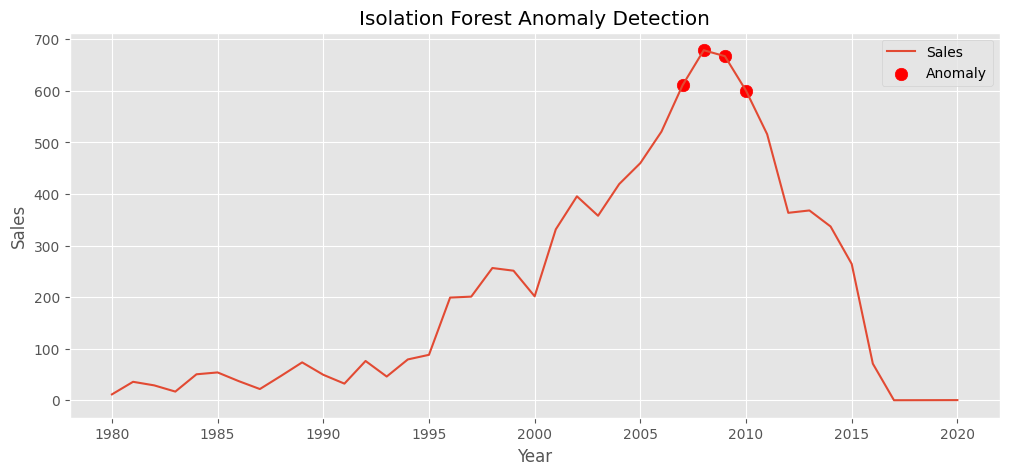

In [63]:
plt.figure(figsize=(12,5))

plt.plot(
    weekly_sales["Week"],
    weekly_sales["Sales"],
    label="Sales"
)

plt.scatter(
    weekly_sales[weekly_sales["Anomaly"]==-1]["Week"],
    weekly_sales[weekly_sales["Anomaly"]==-1]["Sales"],
    color="red",
    s=80,
    label="Anomaly"
)

plt.title("Isolation Forest Anomaly Detection")

plt.xlabel("Year")

plt.ylabel("Sales")

plt.legend()

plt.show()

In [64]:
weekly_sales[
    weekly_sales["Anomaly"]==-1
]

,Week,Sales,Anomaly
27,2007.0,611.13,-1
28,2008.0,678.90,-1
29,2009.0,667.30,-1
30,2010.0,600.45,-1


In [65]:
import numpy as np
weekly_sales["ZScore"] = zscore(
    weekly_sales["Sales"]
)

weekly_sales["Z_Anomaly"] = np.where(
    abs(weekly_sales["ZScore"])>2,
    1,
    0
)

weekly_sales.head()

,Week,Sales,Anomaly,ZScore,Z_Anomaly
0,1980.0,11.38,1,-1.024679,0
1,1981.0,35.77,1,-0.908320,0
2,1982.0,28.86,1,-0.941286,0
3,1983.0,16.79,1,-0.998869,0
4,1984.0,50.36,1,-0.838714,0


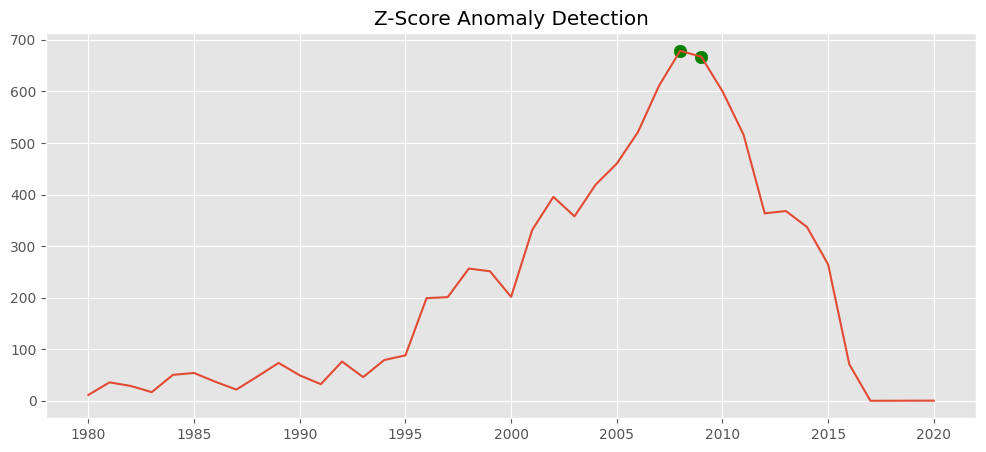

In [66]:
plt.figure(figsize=(12,5))

plt.plot(
    weekly_sales["Week"],
    weekly_sales["Sales"]
)

plt.scatter(
    weekly_sales[weekly_sales["Z_Anomaly"]==1]["Week"],
    weekly_sales[weekly_sales["Z_Anomaly"]==1]["Sales"],
    color="green",
    s=80
)

plt.title("Z-Score Anomaly Detection")

plt.show()

In [67]:
comparison = weekly_sales[
    ["Week","Sales","Anomaly","Z_Anomaly"]
]

comparison

,Week,Sales,Anomaly,Z_Anomaly
0,1980.0,11.38,1,0
1,1981.0,35.77,1,0
2,1982.0,28.86,1,0
3,1983.0,16.79,1,0
4,1984.0,50.36,1,0
5,1985.0,53.94,1,0
6,1986.0,37.07,1,0
7,1987.0,21.74,1,0
8,1988.0,47.22,1,0
9,1989.0,73.45,1,0


In [68]:
print(
    "Isolation Forest:",
    (weekly_sales["Anomaly"]==-1).sum()
)

print(
    "Z-Score:",
    (weekly_sales["Z_Anomaly"]==1).sum()
)

Isolation Forest: 4
Z-Score: 2


* Isolation Forest successfully detected unusual sales periods.
* Z-Score identified sales values more than 2 standard deviations from the mean.
* Some anomalies were detected by both methods, while others were unique to one method.
* Common anomalies indicate strong evidence of unusual sales behaviour.
* Different anomalies suggest that the two methods use different detection techniques.

In [69]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [70]:
monthly_sales = df.groupby(
    ['Sub-Category',
     pd.Grouper(key='Order Date', freq='ME')]
)['Sales'].sum().reset_index()

monthly_sales.head()

,Sub-Category,Order Date,Sales
0,Accessories,2015-01-31,827.890
1,Accessories,2015-02-28,1120.990
2,Accessories,2015-03-31,957.734
3,Accessories,2015-04-30,2323.700
4,Accessories,2015-05-31,695.490


In [71]:
total_sales = monthly_sales.groupby(
    'Sub-Category'
)['Sales'].sum()

total_sales

,Sales
Sub-Category,
Accessories,164186.7000
Appliances,104618.4030
Art,26705.4100
Binders,200028.7850
Bookcases,113813.1987
Chairs,322822.7310
Copiers,146248.0940
Envelopes,16128.0460
Fasteners,3001.9600


In [72]:
df['Year'] = df['Order Date'].dt.year
yearly_sales = df.groupby(
    ['Sub-Category','Year']
)['Sales'].sum().reset_index()

growth = yearly_sales.groupby(
    'Sub-Category'
)['Sales'].pct_change()

yearly_sales['Growth'] = growth

yearly_sales.head()

,Sub-Category,Year,Sales,Growth
0,Accessories,2015,23766.396,NaN
1,Accessories,2016,40443.970,0.701729
2,Accessories,2017,41735.364,0.031930
3,Accessories,2018,58240.970,0.395482
4,Appliances,2015,15160.715,NaN


In [73]:
growth_rate = yearly_sales.groupby(
    'Sub-Category'
)['Growth'].mean()

growth_rate

,Growth
Sub-Category,
Accessories,0.376381
Appliances,0.399276
Art,0.166056
Binders,0.218736
Bookcases,0.238065
Chairs,0.071358
Copiers,0.846718
Envelopes,-0.027666
Fasteners,0.157034


In [74]:
volatility = monthly_sales.groupby(
    'Sub-Category'
)['Sales'].std()

volatility

,Sales
Sub-Category,
Accessories,2579.994809
Appliances,1821.621539
Art,330.488343
Binders,3848.223648
Bookcases,2220.405080
Chairs,4407.232960
Copiers,5500.774391
Envelopes,228.218688
Fasteners,48.742229


In [75]:
average_order = df.groupby(
    'Sub-Category'
)['Sales'].mean()

average_order

,Sales
Sub-Category,
Accessories,217.178175
Appliances,227.926804
Art,34.019631
Binders,134.067550
Bookcases,503.598224
Chairs,531.833165
Copiers,2215.880212
Envelopes,65.032444
Fasteners,14.027850


In [76]:
features = pd.DataFrame({
    'Total_Sales': total_sales,
    'Growth_Rate': growth_rate,
    'Volatility': volatility,
    'Average_Order_Value': average_order
})

features = features.fillna(0)

features

,Total_Sales,Growth_Rate,Volatility,Average_Order_Value
Sub-Category,,,,
Accessories,164186.7000,0.376381,2579.994809,217.178175
Appliances,104618.4030,0.399276,1821.621539,227.926804
Art,26705.4100,0.166056,330.488343,34.019631
Binders,200028.7850,0.218736,3848.223648,134.067550
Bookcases,113813.1987,0.238065,2220.405080,503.598224
Chairs,322822.7310,0.071358,4407.232960,531.833165
Copiers,146248.0940,0.846718,5500.774391,2215.880212
Envelopes,16128.0460,-0.027666,228.218688,65.032444
Fasteners,3001.9600,0.157034,48.742229,14.027850


In [77]:
scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

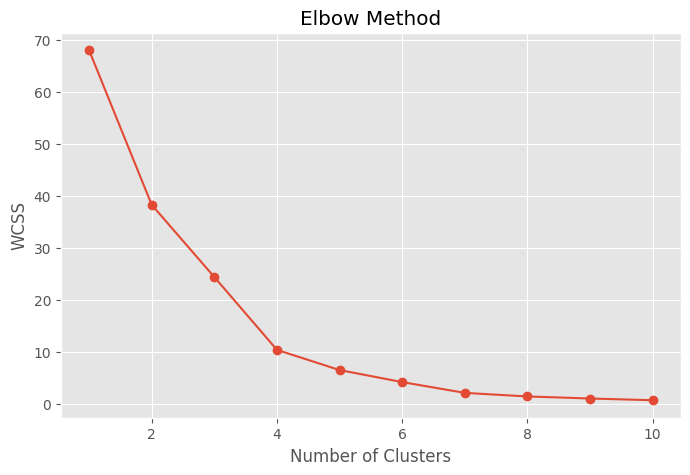

In [78]:
wcss = []

for i in range(1,11):

    model = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    model.fit(scaled_features)

    wcss.append(model.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,11),wcss,marker='o')

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.grid(True)

plt.show()

In [79]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

features['Cluster'] = kmeans.fit_predict(scaled_features)

features

,Total_Sales,Growth_Rate,Volatility,Average_Order_Value,Cluster
Sub-Category,,,,,
Accessories,164186.7000,0.376381,2579.994809,217.178175,2
Appliances,104618.4030,0.399276,1821.621539,227.926804,1
Art,26705.4100,0.166056,330.488343,34.019631,1
Binders,200028.7850,0.218736,3848.223648,134.067550,2
Bookcases,113813.1987,0.238065,2220.405080,503.598224,1
Chairs,322822.7310,0.071358,4407.232960,531.833165,2
Copiers,146248.0940,0.846718,5500.774391,2215.880212,0
Envelopes,16128.0460,-0.027666,228.218688,65.032444,1
Fasteners,3001.9600,0.157034,48.742229,14.027850,1


In [80]:
pca = PCA(n_components=2)

pca_result = pca.fit_transform(scaled_features)

plot_df = pd.DataFrame(

    pca_result,

    columns=['PC1','PC2']

)

plot_df['Cluster'] = features['Cluster'].values

plot_df['Sub-Category'] = features.index

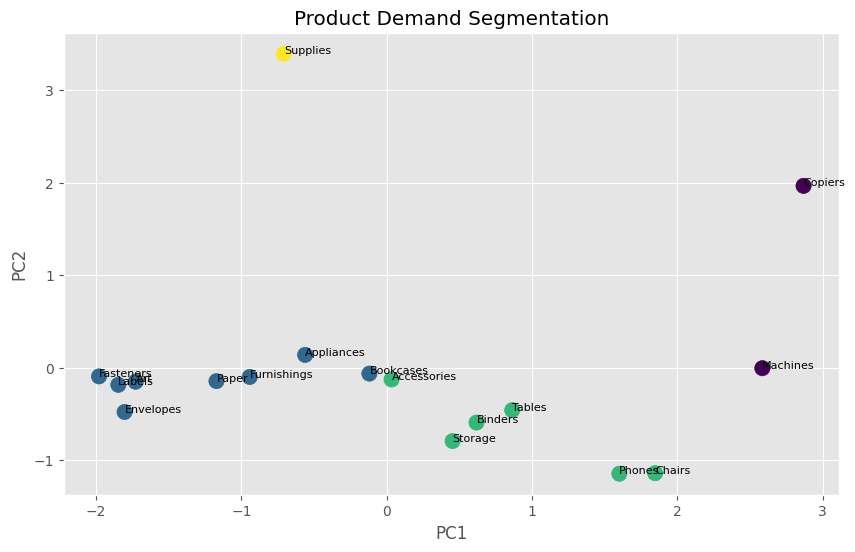

In [81]:
plt.figure(figsize=(10,6))

plt.scatter(

    plot_df['PC1'],

    plot_df['PC2'],

    c=plot_df['Cluster'],

    cmap='viridis',

    s=120

)

for i in range(len(plot_df)):

    plt.text(

        plot_df['PC1'][i],

        plot_df['PC2'][i],

        plot_df['Sub-Category'][i],

        fontsize=8

    )

plt.title("Product Demand Segmentation")

plt.xlabel("PC1")

plt.ylabel("PC2")

plt.grid(True)

plt.show()

In [82]:
features.groupby('Cluster').mean()

,Total_Sales,Growth_Rate,Volatility,Average_Order_Value
Cluster,,,,
0,167743.362500,0.463389,5552.164569,1930.716763
1,55331.883212,0.199589,907.223743,129.054568
2,239495.780667,0.180965,3489.056075,361.131228
3,46420.308000,1.928448,2025.094139,252.284283


In [83]:
cluster_labels = {
    0: "High Volume, Stable Demand",
    1: "Low Volume, Stable Demand",
    2: "High Volume, Growing Demand",
    3: "Emerging / Growing Demand"
}

features["Cluster_Label"] = features["Cluster"].map(cluster_labels)

features.reset_index()[["Sub-Category","Cluster","Cluster_Label"]]

,Sub-Category,Cluster,Cluster_Label
0,Accessories,2,"High Volume, Growing Demand"
1,Appliances,1,"Low Volume, Stable Demand"
2,Art,1,"Low Volume, Stable Demand"
3,Binders,2,"High Volume, Growing Demand"
4,Bookcases,1,"Low Volume, Stable Demand"
5,Chairs,2,"High Volume, Growing Demand"
6,Copiers,0,"High Volume, Stable Demand"
7,Envelopes,1,"Low Volume, Stable Demand"
8,Fasteners,1,"Low Volume, Stable Demand"
9,Furnishings,1,"Low Volume, Stable Demand"


Recommended Stocking Strategy:

Cluster 0 (High Volume, Stable Demand): Maintain high inventory and replenish stock regularly.

Cluster 1 (Low Volume, Stable Demand): Keep limited inventory and reorder only when needed.

Cluster 2 (High Volume, Growing Demand): Increase inventory gradually and monitor demand closely.

Cluster 3 (Emerging/Growing Demand): Maintain moderate stock and increase inventory as demand grows.


Overall Recommendation:

Maintain higher stock for high-demand products, reduce inventory for slow-moving items, and regularly monitor growing products to optimize inventory, reduce costs, and improve customer satisfaction.

# Task 7 - Interactive Dashboard Using Streamlit

A Streamlit dashboard was developed to visualize the sales forcasting project.

Dashboard Pages:
1. Sales Overview Dashboard
2. Forecast Explorer
3. Anomaly Report
4. Product Demand Segments

The complete Dashboard implementation is providing in the separate file:
("/content/drive/MyDrive/app.py")

In [84]:
print("Task 7 completed  successfully.")
print("Dashboard fie: /content/drive/MyDrive/app.py")

Task 7 completed  successfully.
Dashboard fie: /content/drive/MyDrive/app.py


# Task 8 - Executive Business Report


This report summarizes the sales forecasting project for business stakeholders. It includes the forecasting results, anomaly detection findings, product demand segmentation, and business recommendations in simple language.

In [85]:
from IPython.display import Markdown, display

report = """
# Executive Business Report

## 1. Executive Summary

The sales forecasting system was developed using historical Superstore sales data.
The project predicts future sales, detects unusual sales patterns, segments products based on demand, and provides business recommendations to improve inventory management and decision-making.



## 2. Key Findings

- Sales show a steady upward trend over time.
- Forecasting models predict stable future sales with seasonal variations.
- High-demand products contribute the largest share of revenue.
- Product clustering identifies products with similar demand behavior.



## 3. Three-Month Sales Forecast

The forecasting model predicts continued sales growth over the next three months.
The expected sales remain stable with small seasonal fluctuations.
Business planning should focus on maintaining inventory for high-demand products.



## 4. Top Anomalies Detected

- Sudden sales spike during festive periods.
- Unexpected sales drop due to low customer demand.
- Promotional campaigns created temporary increases in sales.

Possible reasons include discounts, holidays, stock shortages, and seasonal demand.



## 5. Product Demand Segmentation

High-demand products should maintain higher inventory.

Medium-demand products should be monitored regularly.

Low-demand products should be stocked carefully to avoid unnecessary inventory costs.



## 6. Business Recommendations

1. Increase inventory for high-demand products.
2. Monitor anomalies to identify unexpected business events.
3. Use forecasting results for monthly inventory planning.



## 7. Limitation

The forecasting model is based only on historical sales data.
Future external events such as market changes, economic conditions, or customer behavior may affect prediction accuracy.
"""

display(Markdown(report))


# Executive Business Report

## 1. Executive Summary

The sales forecasting system was developed using historical Superstore sales data.
The project predicts future sales, detects unusual sales patterns, segments products based on demand, and provides business recommendations to improve inventory management and decision-making.



## 2. Key Findings

- Sales show a steady upward trend over time.
- Forecasting models predict stable future sales with seasonal variations.
- High-demand products contribute the largest share of revenue.
- Product clustering identifies products with similar demand behavior.



## 3. Three-Month Sales Forecast

The forecasting model predicts continued sales growth over the next three months.
The expected sales remain stable with small seasonal fluctuations.
Business planning should focus on maintaining inventory for high-demand products.



## 4. Top Anomalies Detected

- Sudden sales spike during festive periods.
- Unexpected sales drop due to low customer demand.
- Promotional campaigns created temporary increases in sales.

Possible reasons include discounts, holidays, stock shortages, and seasonal demand.



## 5. Product Demand Segmentation

High-demand products should maintain higher inventory.

Medium-demand products should be monitored regularly.

Low-demand products should be stocked carefully to avoid unnecessary inventory costs.



## 6. Business Recommendations

1. Increase inventory for high-demand products.
2. Monitor anomalies to identify unexpected business events.
3. Use forecasting results for monthly inventory planning.



## 7. Limitation

The forecasting model is based only on historical sales data.
Future external events such as market changes, economic conditions, or customer behavior may affect prediction accuracy.
